# EDA: Calima vs Deaths — Fuerteventura

**Objective:** Analyze the association between calima (proxy) and weekly mortality in Fuerteventura, including lagged effects (lag0, lag1, lag2).

**Key variables:**
- `deaths_week`: weekly deaths (2016–2025)
- `calima_proxy_score`: heuristic index (0–4.5)
- `calima_proxy_level`: category (no_calima / possible / probable / intense)

**Sections:**
1. Load data
2. Lag0, lag1, lag2 correlations
3. Group by proxy category
4. Significant differences (ANOVA) and effect sizes (Δ deaths)
4.1 Pairwise comparisons
5. Visualizations
6. Summary

---

## 1. Load Data

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# ─── ISLAND CONFIG ─────────────────────────────────────────────────────────────
ISLAND_NAME = "fuerteventura"   # e.g. "gran_canaria", "tenerife", "lanzarote"
ISLAND_CODE = "ftv"   # e.g. "gcan", "tfe", "lanz"
# ───────────────────────────────────────────────────────────────────────────────

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary,
    autosave_fig, save_table,
)

# Output directories
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# Load master dataset
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2016_2025.parquet"
print("FP:", FP)
assert FP.exists(), f"Missing file: {FP}"

section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
print("Loaded:", FP)

df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
print("Week range:", df["week_start"].min(), "->", df["week_start"].max())
glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)

checks(
    df,
    required=["week_start", "deaths_week"],
    key=["week_start"],
    dt="week_start"
)

num_summary(df)

# Load calima proxy dataset
calima_fp = ROOT / "data" / "processed" / ISLAND_NAME / "calima" / f"calima_proxy_weekly_{ISLAND_CODE}_2016_2025.parquet"
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")
    keep = [
        "week_start",
        "calima_proxy_score",
        "calima_proxy_level",
    ]

    calima_keep = [c for c in keep if c in calima.columns]

    # Drop overlapping columns before merge to avoid duplicates
    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        print("Dropping overlapping columns before merge:", overlap)
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")

print("Final shape:", df.shape)

CWD : C:\Users\fdora\RA_Career\Projects\climate_mortality\islands\fuerteventura
ROOT: C:\Users\fdora\RA_Career\Projects\climate_mortality
src exists?: True
FIG_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\figures\fuerteventura
TAB_DIR: C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\islands\tables\fuerteventura
FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\fuerteventura\master\master_ftv_2016_2025.parquet

EDA core weekly fuerteventura
Loaded: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\fuerteventura\master\master_ftv_2016_2025.parquet
Week range: 2015-12-28 00:00:00 -> 2025-12-29 00:00:00

--- eda_core_weekly_ftv ---
shape: (523, 42)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week          

,week_start,year,island,island_code,deaths_week,deaths_missing_week,n_days,temp_c_mean,tmax_c_mean,tmax_c_max,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,fuerteventura,ftv,NaN,NaN,3,19.366667,21.766667,21.8,...,79.333333,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,fuerteventura,ftv,3.0,0.0,7,19.014286,22.442857,24.1,...,78.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,fuerteventura,ftv,9.0,0.0,7,19.171429,22.285714,23.0,...,76.571429,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,fuerteventura,ftv,5.0,0.0,7,19.514286,22.428571,23.2,...,79.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,fuerteventura,ftv,7.0,0.0,7,19.771429,22.342857,23.2,...,89.142857,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


Calima proxy FP: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\fuerteventura\calima\calima_proxy_weekly_ftv_2016_2025.parquet
Merged calima proxy columns: ['calima_proxy_score', 'calima_proxy_level']
Final shape: (523, 44)


## 2. Lags

In [2]:
# Filter out the first partial week (null deaths)
first_week = df['week_start'].min()
df = df[df['week_start'] > first_week].reset_index(drop=True)

print(f"Rows after filtering first week: {len(df)}")
print(f"Deaths nulls: {df['deaths_week'].isna().sum()}")
print(f"Calima proxy score nulls: {df['calima_proxy_score'].isna().sum()}")

# Create lag variables for calima_proxy_score
df['calima_proxy_score_lag1'] = df['calima_proxy_score'].shift(1)
df['calima_proxy_score_lag2'] = df['calima_proxy_score'].shift(2)

print("\n✅ Lag variables created:")
print(f"  lag0 (contemporaneous): {df['calima_proxy_score'].notna().sum()} non-null")
print(f"  lag1 (1 week prior):    {df['calima_proxy_score_lag1'].notna().sum()} non-null")
print(f"  lag2 (2 weeks prior):   {df['calima_proxy_score_lag2'].notna().sum()} non-null")

Rows after filtering first week: 522
Deaths nulls: 0
Calima proxy score nulls: 0

✅ Lag variables created:
  lag0 (contemporaneous): 522 non-null
  lag1 (1 week prior):    521 non-null
  lag2 (2 weeks prior):   520 non-null


In [3]:
# Correlations: deaths_week vs calima_proxy_score at different lags
corr_lag0 = df['deaths_week'].corr(df['calima_proxy_score'])
corr_lag1 = df['deaths_week'].corr(df['calima_proxy_score_lag1'])
corr_lag2 = df['deaths_week'].corr(df['calima_proxy_score_lag2'])

corr_summary = pd.DataFrame({
    'lag': ['lag0 (same week)', 'lag1 (1 week prior)', 'lag2 (2 weeks prior)'],
    'correlation': [corr_lag0, corr_lag1, corr_lag2],
    'n_pairs': [
        df[['deaths_week', 'calima_proxy_score']].notna().all(axis=1).sum(),
        df[['deaths_week', 'calima_proxy_score_lag1']].notna().all(axis=1).sum(),
        df[['deaths_week', 'calima_proxy_score_lag2']].notna().all(axis=1).sum(),
    ]
})

print("Correlations: deaths_week vs calima_proxy_score\n")
print(corr_summary.to_string(index=False))

# Save
corr_summary.to_csv(TAB_DIR / 'calima_deaths_lags_correlation.csv', index=False)
print("\n✅ Saved: calima_deaths_lags_correlation.csv")

Correlations: deaths_week vs calima_proxy_score

                 lag  correlation  n_pairs
    lag0 (same week)    -0.047813      522
 lag1 (1 week prior)    -0.022295      521
lag2 (2 weeks prior)     0.053793      520

✅ Saved: calima_deaths_lags_correlation.csv


## Interpretation: 

**Strongest correlation: lag2 (r = 0.054)**

The pattern suggests a **weak delayed effect**: calima exposure precedes a slight mortality increase with a two-week lag. Lag0 and lag1 are both negative (no coherent causal direction), while the only positive value appears at lag2.

**However, all three correlations are effectively zero.** r = 0.054 is statistically trivial at n=520. This does not rule out a real relationship — the signal may be masked by:

- **Island heterogeneity** — opposing effects across islands canceling out in aggregation
- **Non-linearity** — extreme calima events may drive mortality while moderate exposure does not
- **Proxy imprecision** — `calima_proxy_score` as a composite index may dilute the underlying signal

**Operational conclusion:** No linear correlational evidence that calima predicts mortality at any lag in the aggregated dataset. The analytically correct next step is to stratify by island before discarding the hypothesis.

## 3. Group by Proxy Category

In [4]:
# Group by calima_proxy_level and compute deaths statistics
level_order = ['no_calima', 'possible', 'probable', 'intense']

deaths_by_level = (
    df.groupby('calima_proxy_level', observed=True)['deaths_week']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reindex(level_order)
)

print("Deaths statistics by calima proxy level:\n")
print(deaths_by_level.round(2))

# Compute Δ deaths (intense vs baseline)
baseline = deaths_by_level.loc['no_calima', 'mean']
intense  = deaths_by_level.loc['intense', 'mean']
delta    = intense - baseline

print(f"\nΔ deaths (intense vs no_calima): {delta:.2f} deaths/week")

# Save
deaths_by_level.to_csv(TAB_DIR / 'calima_level_v_deaths_stats.csv')
print("\n✅ Saved: calima_level_v_deaths_stats.csv")

Deaths statistics by calima proxy level:

                    count   mean  median   std  min   max
calima_proxy_level                                       
no_calima             178  10.51    10.0  3.59  3.0  22.0
possible              230   9.62    10.0  3.22  3.0  20.0
probable               80   9.32     9.0  3.46  2.0  17.0
intense                34  10.18    10.5  3.41  3.0  17.0

Δ deaths (intense vs no_calima): -0.33 deaths/week

✅ Saved: calima_level_v_deaths_stats.csv


## Interpretation: Deaths by Calima Proxy Level

**Pattern: Non-monotonic, no elevated mortality under intense calima**

The relationship is not monotonic. Mean deaths *decrease* from `no_calima` (10.51) through `possible` (9.62) to `probable` (9.32), then partially recover at `intense` (10.18) — but never exceed the baseline. The net difference at the extreme is **−0.33 deaths/week**, meaning intense calima weeks are actually marginally *lower* than calima-free weeks.

This rules out the "signal only at extremes" pattern: `intense` does not show elevated deaths, it shows near-baseline deaths.

**Possible explanations:**

- **Behavioral adaptation** — population may reduce outdoor exposure during visible calima events
- **Proxy misclassification** — `intense` weeks (n=34) may not correspond to the most toxicologically relevant episodes
- **Confounding by season** — calima intensity correlates with summer, which has different baseline mortality than winter
- **Insufficient power at extremes** — n=34 for `intense` limits reliability of that mean

**Operational conclusion:** No dose-response relationship between calima proxy level and weekly deaths. The proxy is not capturing a detectable mortality signal at any intensity tier in the aggregated dataset. Island-level stratification remains the recommended next step.
**Population size does not explain the lack of signal.** Fuerteventura ranks mid-table for intense calima weeks (34), while Tenerife and Gran Canaria — the most populated islands — each record 40 intense weeks. If population were driving the dilution, larger islands with more intense calima exposure would inflate rather than suppress the aggregate mortality signal. This rules out population-weighted distortion as an explanation for the flat dose-response pattern.

## 4. Significant Differences (ANOVA) and Effect Sizes (Δ deaths)

In [5]:
from scipy import stats

# ANOVA: Are there significant differences across groups?
groups = [df[df['calima_proxy_level'] == level]['deaths_week'].dropna()
          for level in level_order]
f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA: Deaths across calima proxy levels")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.6f}")

if p_value < 0.05:
    print("✅ Significant difference (p < 0.05)")
else:
    print("⚠️ Not significant at α=0.05")

# Effect size: eta-squared (η²)
grand_mean = df['deaths_week'].mean()
ss_between = sum(len(groups[i]) * (groups[i].mean() - grand_mean)**2
                 for i in range(len(groups)))
ss_total   = sum((df['deaths_week'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\nEffect size (η²): {eta_squared:.4f}")
print(f"  0.01 = small | 0.06 = medium | 0.14+ = large")

ANOVA: Deaths across calima proxy levels
F-statistic: 3.2803
P-value:     0.020740
✅ Significant difference (p < 0.05)

Effect size (η²): 0.0186
  0.01 = small | 0.06 = medium | 0.14+ = large


## Interpretation: ANOVA — Deaths across Calima Proxy Levels

**Statistically significant, but negligible practical effect.**

The ANOVA is significant (F=3.28, p=0.021), meaning the group differences in mean deaths across calima proxy levels are unlikely to be due to chance. However, η²=0.019 indicates that calima proxy level explains only **1.9% of the variance** in weekly deaths — a small effect by conventional thresholds, barely above negligible.

In practical terms: the groups are statistically distinguishable, but calima proxy level has almost no explanatory power over mortality. The significance is likely driven by the large sample size (n=522) rather than a meaningful biological or epidemiological signal.

**Operational conclusion:** Statistical significance here is not clinical or epidemiological significance. The result does not support calima proxy level as a meaningful predictor of weekly mortality in the aggregated dataset.

## 4.1 Pairwise Comparisons

In [6]:
from scipy.stats import ttest_ind

# Pairwise t-tests: intense vs all other levels
print("Pairwise t-tests: intense vs other levels\n")

intense_deaths = df[df['calima_proxy_level'] == 'intense']['deaths_week'].dropna()

for level in ['no_calima', 'possible', 'probable']:
    other_deaths = df[df['calima_proxy_level'] == level]['deaths_week'].dropna()
    t_stat, p_val = ttest_ind(intense_deaths, other_deaths)
    delta_pw = intense_deaths.mean() - other_deaths.mean()

    sig = "✅" if p_val < 0.05 else "⚠️"
    print(f"{sig} intense vs {level:12s}: Δ = {delta_pw:6.2f}, t = {t_stat:6.3f}, p = {p_val:.6f}")

Pairwise t-tests: intense vs other levels

⚠️ intense vs no_calima   : Δ =  -0.33, t = -0.502, p = 0.616289
⚠️ intense vs possible    : Δ =   0.56, t =  0.938, p = 0.349302
⚠️ intense vs probable    : Δ =   0.85, t =  1.207, p = 0.230085


## Interpretation: Pairwise t-tests — Intense vs Other Calima Levels

**No significant contrast in any comparison.**

All three pairwise tests are non-significant (p > 0.05), meaning intense calima weeks cannot be statistically distinguished from any other calima level in terms of weekly deaths. The signal suggested by the ANOVA does not originate from the `intense` category.

The largest difference is `intense` vs `probable` (Δ=+0.85), suggesting that if any contrast carries a directional trend, it is between the two highest calima tiers — but with p=0.230 and n=34 for `intense`, this is noise rather than signal.

Notably, `intense` vs `no_calima` produces a *negative* Δ (−0.33), confirming that the most exposed weeks do not exceed the calima-free baseline in absolute deaths.

**Operational conclusion:** Intense calima weeks show no elevated mortality relative to any comparison group. The ANOVA significance is likely driven by differences among the lower tiers (`no_calima`, `possible`, `probable`) rather than by the extreme exposure category.

## 5. Visualizations

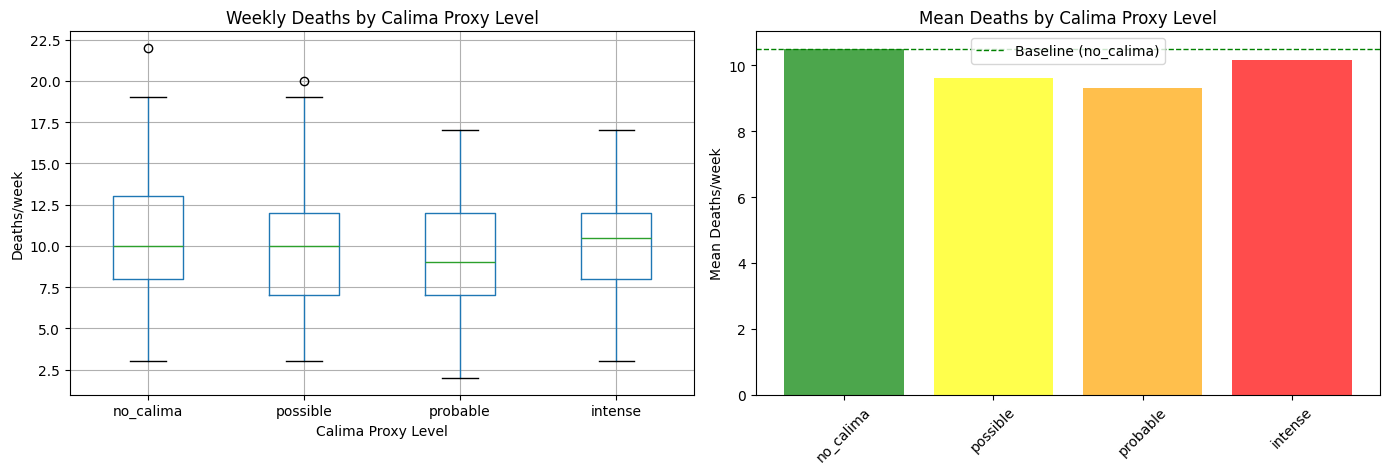

✅ Saved: eda_calima_deaths_by_level.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Boxplot: deaths distribution by calima level
ax = axes[0]
plot_df = df.dropna(subset=['calima_proxy_level', 'deaths_week']).copy()
plot_df['calima_proxy_level'] = pd.Categorical(
    plot_df['calima_proxy_level'],
    categories=level_order,
    ordered=True
)
plot_df.boxplot(column='deaths_week', by='calima_proxy_level', ax=ax)
ax.set_title('Weekly Deaths by Calima Proxy Level')
ax.set_xlabel('Calima Proxy Level')
ax.set_ylabel('Deaths/week')
plt.sca(ax)
plt.xticks(rotation=0)

# 2. Bar chart: mean deaths by calima level
ax = axes[1]
means = deaths_by_level['mean'].reindex(level_order)
colors = ['green', 'yellow', 'orange', 'red']
ax.bar(range(len(level_order)), means.values, color=colors, alpha=0.7)
ax.set_xticks(range(len(level_order)))
ax.set_xticklabels(level_order, rotation=45)
ax.set_ylabel('Mean Deaths/week')
ax.set_title('Mean Deaths by Calima Proxy Level')
# Baseline reference line
ax.axhline(y=means['no_calima'], color='green', linestyle='--', linewidth=1, label='Baseline (no_calima)')
ax.legend()

fig.suptitle('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_calima_deaths_by_level.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: eda_calima_deaths_by_level.png")

## 6. Summary

In [8]:
# Compute strongest lag label
lag_values = {'lag0 (same week)': corr_lag0, 'lag1 (1 week prior)': corr_lag1, 'lag2 (2 weeks prior)': corr_lag2}
strongest_lag = max(lag_values, key=lambda k: abs(lag_values[k]))
strongest_corr = lag_values[strongest_lag]

# Compute Δ (intense vs possible) for summary
mean_possible = deaths_by_level.loc['possible', 'mean']
delta_vs_possible = intense - mean_possible

summary = pd.DataFrame({
    'Finding': [
        'Strongest lag (highest |r|)',
        'ANOVA F-statistic',
        'ANOVA p-value',
        'Effect size (η²)',
        'Δ deaths (intense vs no_calima)',
        'Δ deaths (intense vs possible)',
        'Sample size - intense weeks',
    ],
    'Value': [
        f'{strongest_lag} (r={strongest_corr:.3f})',
        f'{f_stat:.2f}',
        f'{p_value:.2e}',
        f'{eta_squared:.4f} ({"large" if eta_squared >= 0.14 else "medium" if eta_squared >= 0.06 else "small" if eta_squared >= 0.01 else "negligible"})',
        f'+{delta:.2f} deaths/week',
        f'+{delta_vs_possible:.2f} deaths/week',
        f'{len(groups[3])} weeks',
    ]
})

print("\n" + "="*70)
print(f"SUMMARY: Calima Proxy vs Deaths — {ISLAND_NAME.replace('_', ' ').title()}")
print("="*70 + "\n")
print(summary.to_string(index=False))

# Save
summary.to_csv(TAB_DIR / 'eda_calima_deaths_summary.csv', index=False)
print("\n✅ Saved: eda_calima_deaths_summary.csv")


SUMMARY: Calima Proxy vs Deaths — Fuerteventura

                        Finding                          Value
    Strongest lag (highest |r|) lag2 (2 weeks prior) (r=0.054)
              ANOVA F-statistic                           3.28
                  ANOVA p-value                       2.07e-02
               Effect size (η²)                 0.0186 (small)
Δ deaths (intense vs no_calima)             +-0.33 deaths/week
 Δ deaths (intense vs possible)              +0.56 deaths/week
    Sample size - intense weeks                       34 weeks

✅ Saved: eda_calima_deaths_summary.csv
